In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, brier_score_loss)
from xgboost import XGBClassifier
import shap

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

SEED = 42
np.random.seed(SEED)

C_FN = 5
C_FP = 1

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cols = [
    "checking_status", "duration", "credit_history", "purpose", "credit_amount",
    "savings", "employment", "installment_rate", "personal_status_sex", "other_debtors",
    "residence_since", "property", "age", "other_installment_plans", "housing",
    "existing_credits", "job", "dependents", "telephone", "foreign_worker", "target",
]

df = pd.read_csv("german.data", sep=r"\s+", header=None, names=cols)
print(df.shape)
df.head(3)

(1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,residence_since,property,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1


In [3]:
mappings = {
    "checking_status": {"A11": "lt_0_DM", "A12": "0_to_200_DM", "A13": "ge_200_DM", "A14": "no_account"},
    "credit_history": {"A30": "no_credits_all_paid", "A31": "all_paid_this_bank", "A32": "existing_paid_duly",
                       "A33": "past_delay", "A34": "critical_account"},
    "purpose": {"A40": "car_new", "A41": "car_used", "A42": "furniture", "A43": "radio_tv", "A44": "appliances",
                "A45": "repairs", "A46": "education", "A47": "vacation", "A48": "retraining",
                "A49": "business", "A410": "other"},
    "savings": {"A61": "lt_100_DM", "A62": "100_to_500_DM", "A63": "500_to_1000_DM",
                "A64": "ge_1000_DM", "A65": "unknown_or_none"},
    "employment": {"A71": "unemployed", "A72": "lt_1_year", "A73": "1_to_4_years",
                   "A74": "4_to_7_years", "A75": "ge_7_years"},
    "personal_status_sex": {"A91": "male_divorced", "A92": "female_div_sep_mar", "A93": "male_single",
                            "A94": "male_married_widowed", "A95": "female_single"},
    "other_debtors": {"A101": "none", "A102": "co_applicant", "A103": "guarantor"},
    "property": {"A121": "real_estate", "A122": "life_insurance", "A123": "car_or_other", "A124": "no_property"},
    "other_installment_plans": {"A141": "bank", "A142": "stores", "A143": "none"},
    "housing": {"A151": "rent", "A152": "own", "A153": "for_free"},
    "job": {"A171": "unemployed_unskilled_nonres", "A172": "unskilled_resident",
            "A173": "skilled_employee", "A174": "management_selfemp_highqual"},
    "telephone": {"A191": "none", "A192": "yes"},
    "foreign_worker": {"A201": "yes", "A202": "no"},
}

for c, m in mappings.items():
    df[c] = df[c].map(m)

assert df.isna().sum().sum() == 0

In [4]:
df["bad"] = df["target"].map({1: 0, 2: 1})
df = df.drop(columns=["target"])

cat_cols = list(mappings.keys())
num_cols = [c for c in df.columns if c not in cat_cols + ["bad"]]

print("kateqorik:", len(cat_cols), "| numerik:", len(num_cols))
print("duplicate:", df.duplicated().sum(), "| missing:", df.isna().sum().sum())
print(df["bad"].value_counts().to_dict(), "-> bad rate", round(df["bad"].mean(), 3))

kateqorik: 13 | numerik: 7
duplicate: 0 | missing: 0
{0: 700, 1: 300} -> bad rate 0.3


In [5]:
X = df.drop(columns=["bad"])
y = df["bad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

train = X_train.copy()
train["bad"] = y_train

print(X_train.shape, X_test.shape)
print("train bad rate:", round(y_train.mean(), 3), "| test bad rate:", round(y_test.mean(), 3))

(800, 20) (200, 20)
train bad rate: 0.3 | test bad rate: 0.3


In [6]:
base = train["bad"].mean()

rows = []
for c in cat_cols:
    t = train.groupby(c)["bad"].agg(["count", "mean"])
    rows.append({
        "feature": c,
        "spread": round(t["mean"].max() - t["mean"].min(), 3),
        "n_cat": len(t),
        "kicik_kat": int((t["count"] < 30).sum()),
    })

ranking = pd.DataFrame(rows).sort_values("spread", ascending=False).reset_index(drop=True)
ranking

,feature,spread,n_cat,kicik_kat
0,credit_history,0.438,5,0
1,checking_status,0.359,4,0
2,purpose,0.310,10,4
3,property,0.255,4,0
4,savings,0.242,5,0
5,other_debtors,0.225,3,0
6,employment,0.218,5,0
7,foreign_worker,0.211,2,0
8,other_installment_plans,0.186,3,0
9,personal_status_sex,0.154,4,0


In [7]:
for c in ["checking_status", "credit_history", "savings"]:
    t = train.groupby(c)["bad"].agg(["count", "mean"]).sort_values("mean", ascending=False)
    t["lift"] = (t["mean"] / base).round(2)
    t["mean"] = t["mean"].round(3)
    print(f"--- {c}")
    print(t, "\n")

--- checking_status
                 count   mean  lift
checking_status                    
lt_0_DM            219  0.479  1.60
0_to_200_DM        214  0.393  1.31
ge_200_DM           51  0.255  0.85
no_account         316  0.120  0.40 

--- credit_history
                     count   mean  lift
credit_history                         
no_credits_all_paid     31  0.613  2.04
all_paid_this_bank      41  0.537  1.79
existing_paid_duly     416  0.322  1.07
past_delay              72  0.319  1.06
critical_account       240  0.175  0.58 

--- savings
                 count   mean  lift
savings                            
lt_100_DM          475  0.364  1.21
100_to_500_DM       90  0.333  1.11
unknown_or_none    144  0.167  0.56
500_to_1000_DM      50  0.160  0.53
ge_1000_DM          41  0.122  0.41 



In [8]:
print(train[num_cols].describe().round(2))
print("\nskew:")
print(train[num_cols].skew().round(2))

       duration  credit_amount  installment_rate  residence_since     age  existing_credits  dependents
count    800.00         800.00            800.00           800.00  800.00            800.00      800.00
mean      20.77        3189.59              2.94             2.83   35.32              1.41        1.16
std       11.82        2673.55              1.12             1.11   11.05              0.57        0.37
min        4.00         276.00              1.00             1.00   19.00              1.00        1.00
25%       12.00        1353.00              2.00             2.00   27.00              1.00        1.00
50%       18.00        2317.00              3.00             3.00   33.00              1.00        1.00
75%       24.00        3933.00              4.00             4.00   41.00              2.00        1.00
max       60.00       15945.00              4.00             4.00   75.00              4.00        2.00

skew:
duration            1.05
credit_amount       1.83
install

In [9]:
for c in ["duration", "credit_amount", "age"]:
    b = pd.qcut(train[c], q=5, duplicates="drop")
    print(f"--- {c}")
    print(train.groupby(b, observed=True)["bad"].agg(["count", "mean"]).round(3), "\n")

--- duration
               count   mean
duration                   
(3.999, 12.0]    288  0.205
(12.0, 15.0]      60  0.183
(15.0, 24.0]     270  0.341
(24.0, 30.0]      44  0.318
(30.0, 60.0]     138  0.464 

--- credit_amount
                   count   mean
credit_amount                  
(275.999, 1256.2]    160  0.306
(1256.2, 1890.6]     160  0.238
(1890.6, 2815.2]     160  0.288
(2815.2, 4629.8]     160  0.269
(4629.8, 15945.0]    160  0.400 

--- age
                count   mean
age                         
(18.999, 26.0]    185  0.378
(26.0, 30.0]      143  0.301
(30.0, 36.0]      183  0.268
(36.0, 44.0]      136  0.265
(44.0, 75.0]      153  0.275 



In [10]:
print(train[num_cols].corr().round(2))

                  duration  credit_amount  installment_rate  residence_since   age  existing_credits  dependents
duration              1.00           0.64              0.10             0.02 -0.04              0.01       -0.01
credit_amount         0.64           1.00             -0.24             0.03  0.03              0.05        0.04
installment_rate      0.10          -0.24              1.00             0.07  0.08              0.03       -0.08
residence_since       0.02           0.03              0.07             1.00  0.24              0.09        0.04
age                  -0.04           0.03              0.08             0.24  1.00              0.15        0.11
existing_credits      0.01           0.05              0.03             0.09  0.15              1.00        0.11
dependents           -0.01           0.04             -0.08             0.04  0.11              0.11        1.00


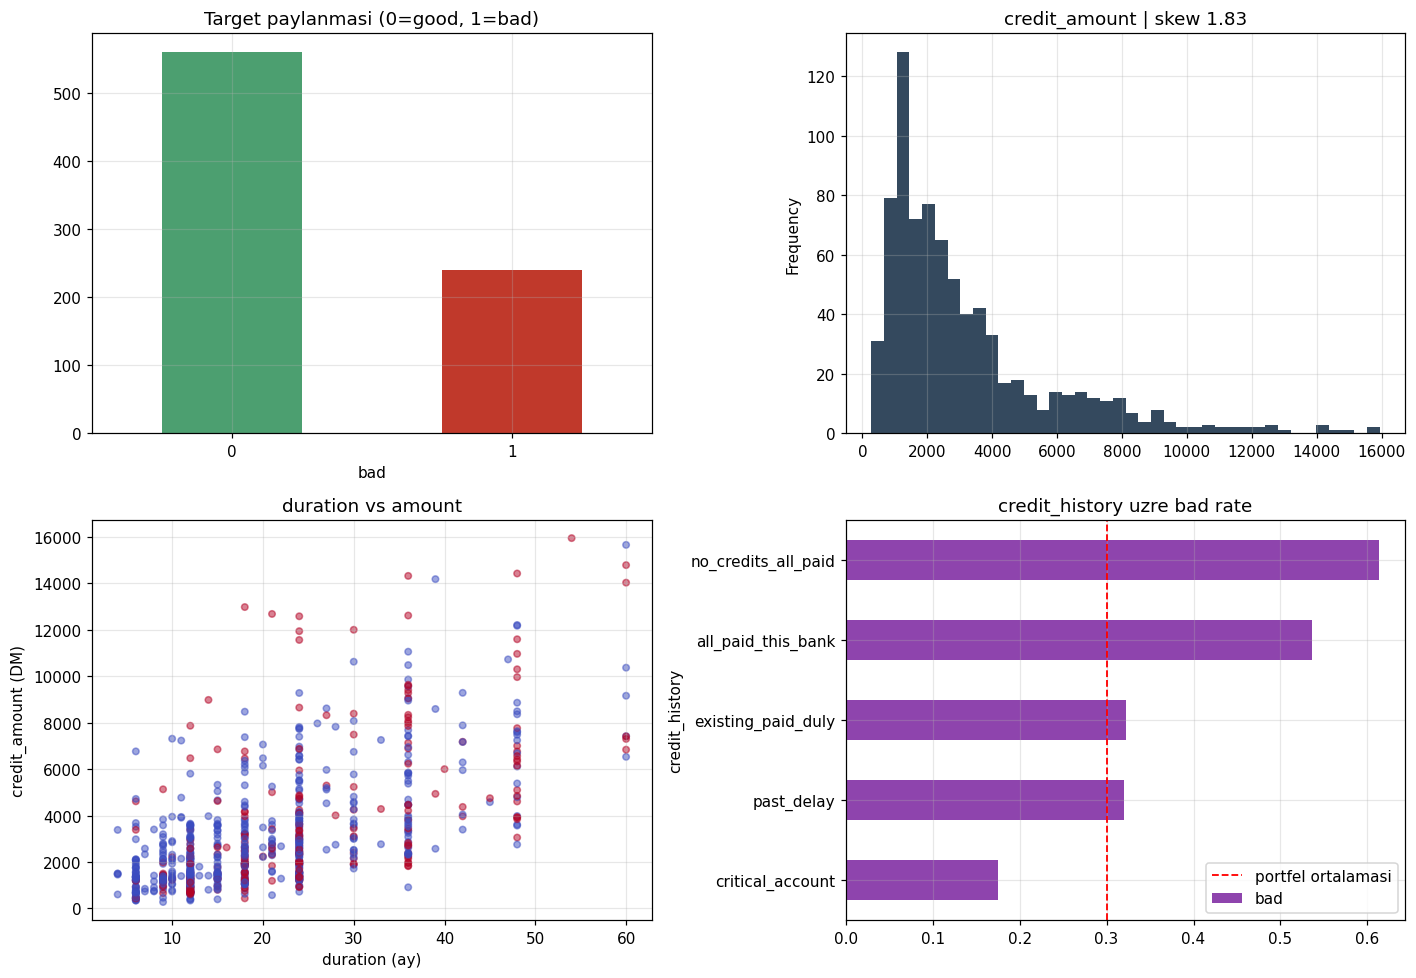

In [11]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

train["bad"].value_counts().sort_index().plot(kind="bar", ax=ax[0, 0], color=["#4C9F70", "#C0392B"])
ax[0, 0].set_title("Target paylanmasi (0=good, 1=bad)")
ax[0, 0].tick_params(axis="x", rotation=0)

train["credit_amount"].plot(kind="hist", bins=40, ax=ax[0, 1], color="#34495E")
ax[0, 1].set_title(f"credit_amount | skew {train['credit_amount'].skew():.2f}")

sc = ax[1, 0].scatter(train["duration"], train["credit_amount"], c=train["bad"],
                      cmap="coolwarm", alpha=0.5, s=18)
ax[1, 0].set_xlabel("duration (ay)"); ax[1, 0].set_ylabel("credit_amount (DM)")
ax[1, 0].set_title("duration vs amount")

train.groupby("credit_history")["bad"].mean().sort_values().plot(kind="barh", ax=ax[1, 1], color="#8E44AD")
ax[1, 1].axvline(base, color="red", ls="--", lw=1.2, label="portfel ortalamasi")
ax[1, 1].set_title("credit_history uzre bad rate")
ax[1, 1].legend()

plt.tight_layout()
plt.show()

In [12]:
train["gender"] = np.where(train["personal_status_sex"] == "female_div_sep_mar", "female", "male")
train["age_group"] = np.where(train["age"] < 26, "young", "adult")

print(train.groupby(["gender", "age_group"])["bad"].agg(["count", "mean"]).round(3))

                  count   mean
gender age_group              
female adult        169  0.314
       young         80  0.450
male   adult        485  0.262
       young         66  0.364


In [13]:
ohe_kw = dict(min_frequency=20, handle_unknown="infrequent_if_exist", sparse_output=False)

prep_linear = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", **ohe_kw), cat_cols),
])

prep_tree = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(**ohe_kw), cat_cols),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_probs(model, X, yy):
    return cross_val_predict(model, X, yy, cv=cv, method="predict_proba")[:, 1]

def total_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * C_FP + fn * C_FN

In [14]:
logreg = Pipeline([
    ("prep", prep_linear),
    ("clf", LogisticRegression(max_iter=2000, random_state=SEED)),
])

logreg_bal = Pipeline([
    ("prep", prep_linear),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
])

results = {}
for name, model in [("logreg", logreg), ("logreg_balanced", logreg_bal)]:
    p = cv_probs(model, X_train, y_train)
    results[name] = p
    print(f"{name:18s} AUC {roc_auc_score(y_train, p):.4f} | PR-AUC {average_precision_score(y_train, p):.4f}")

logreg             AUC 0.7748 | PR-AUC 0.5945


logreg_balanced    AUC 0.7737 | PR-AUC 0.5899


In [15]:
spw = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight =", round(spw, 2))

def make_xgb(**kw):
    params = dict(n_estimators=400, learning_rate=0.05, max_depth=3, subsample=0.8,
                  colsample_bytree=0.8, reg_lambda=1.0, min_child_weight=3,
                  eval_metric="logloss", random_state=SEED, n_jobs=-1)
    params.update(kw)
    return Pipeline([("prep", prep_tree), ("clf", XGBClassifier(**params))])

for name, model in [("xgb", make_xgb()), ("xgb_spw", make_xgb(scale_pos_weight=spw))]:
    p = cv_probs(model, X_train, y_train)
    results[name] = p
    print(f"{name:18s} AUC {roc_auc_score(y_train, p):.4f} | PR-AUC {average_precision_score(y_train, p):.4f}")

scale_pos_weight = 2.33


xgb                AUC 0.7872 | PR-AUC 0.5989


xgb_spw            AUC 0.7865 | PR-AUC 0.5988


In [16]:
grid = {
    "clf__max_depth": [2, 3, 4],
    "clf__learning_rate": [0.02, 0.05, 0.1],
    "clf__n_estimators": [200, 400, 600],
    "clf__subsample": [0.7, 0.8, 1.0],
    "clf__colsample_bytree": [0.6, 0.8, 1.0],
    "clf__min_child_weight": [1, 3, 5],
    "clf__reg_lambda": [0.5, 1.0, 3.0],
}

search = RandomizedSearchCV(
    make_xgb(), grid, n_iter=40, scoring="roc_auc", cv=cv,
    random_state=SEED, n_jobs=-1, refit=True,
)
search.fit(X_train, y_train)

print("en yaxsi CV AUC:", round(search.best_score_, 4))
print({k.replace("clf__", ""): v for k, v in search.best_params_.items()})

xgb_best = search.best_estimator_
results["xgb_tuned"] = cv_probs(xgb_best, X_train, y_train)
print("xgb_tuned OOF AUC:", round(roc_auc_score(y_train, results["xgb_tuned"]), 4))

en yaxsi CV AUC: 0.7979
{'subsample': 1.0, 'reg_lambda': 1.0, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.6}


xgb_tuned OOF AUC: 0.7961


In [17]:
cmp = pd.DataFrame([
    {"model": k,
     "AUC": roc_auc_score(y_train, v),
     "PR_AUC": average_precision_score(y_train, v),
     "Brier": brier_score_loss(y_train, v)}
    for k, v in results.items()
]).sort_values("AUC", ascending=False).reset_index(drop=True)

cmp.round(4)

,model,AUC,PR_AUC,Brier
0,xgb_tuned,0.7961,0.6063,0.1616
1,xgb,0.7872,0.5989,0.1674
2,xgb_spw,0.7865,0.5988,0.1768
3,logreg,0.7748,0.5945,0.1710
4,logreg_balanced,0.7737,0.5899,0.1934


In [18]:
best_model_name = cmp.iloc[0]["model"]
print("secilen model:", best_model_name)
oof = results[best_model_name]

ths = np.linspace(0.02, 0.95, 200)
costs = np.array([total_cost(y_train, (oof >= t).astype(int)) for t in ths])

t_opt = ths[costs.argmin()]
t_theory = C_FP / (C_FP + C_FN)

print(f"empirik optimal threshold : {t_opt:.3f}  -> cost {costs.min()}")
print(f"nezeri threshold          : {t_theory:.3f}")
print(f"default 0.5               -> cost {total_cost(y_train, (oof >= 0.5).astype(int))}")

secilen model: xgb_tuned
empirik optimal threshold : 0.174  -> cost 405
nezeri threshold          : 0.167
default 0.5               -> cost 700


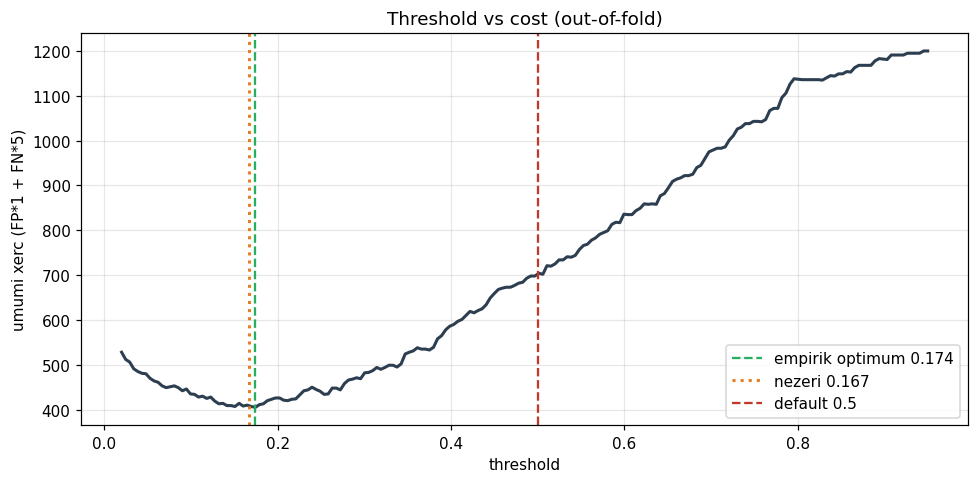

In [19]:
plt.figure(figsize=(9, 4.5))
plt.plot(ths, costs, lw=2, color="#2C3E50")
plt.axvline(t_opt, color="#27AE60", ls="--", label=f"empirik optimum {t_opt:.3f}")
plt.axvline(t_theory, color="#E67E22", ls=":", lw=2, label=f"nezeri {t_theory:.3f}")
plt.axvline(0.5, color="#C0392B", ls="--", label="default 0.5")
plt.xlabel("threshold"); plt.ylabel("umumi xerc (FP*1 + FN*5)")
plt.title("Threshold vs cost (out-of-fold)")
plt.legend(); plt.tight_layout(); plt.show()

In [20]:
THRESHOLD = float(t_opt)
print("istifade edilecek threshold:", round(THRESHOLD, 3))

istifade edilecek threshold: 0.174


In [21]:
final_model = {"logreg": logreg, "logreg_balanced": logreg_bal,
               "xgb": make_xgb(), "xgb_spw": make_xgb(scale_pos_weight=spw),
               "xgb_tuned": xgb_best}[best_model_name]

final_model.fit(X_train, y_train)
p_test = final_model.predict_proba(X_test)[:, 1]

print(f"Test AUC    : {roc_auc_score(y_test, p_test):.4f}")
print(f"Test PR-AUC : {average_precision_score(y_test, p_test):.4f}")

Test AUC    : 0.7904
Test PR-AUC : 0.6346


In [22]:
rows = []
for label, t in [("default 0.5", 0.5), ("nezeri", t_theory), ("secilen", THRESHOLD)]:
    pred = (p_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({
        "qerar qaydasi": label, "threshold": round(t, 3),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "recall(bad)": round(tp / (tp + fn), 3),
        "precision(bad)": round(tp / (tp + fp), 3) if (tp + fp) else np.nan,
        "approve %": round((pred == 0).mean() * 100, 1),
        "COST": fp * C_FP + fn * C_FN,
    })

pd.DataFrame(rows)

,qerar qaydasi,threshold,TP,FP,FN,TN,recall(bad),precision(bad),approve %,COST
0,default 0.5,0.500,30,20,30,120,0.500,0.600,75.0,170
1,nezeri,0.167,50,67,10,73,0.833,0.427,41.5,117
2,secilen,0.174,50,67,10,73,0.833,0.427,41.5,117


              precision    recall  f1-score   support

        good      0.880     0.521     0.655       140
         bad      0.427     0.833     0.565        60

    accuracy                          0.615       200
   macro avg      0.653     0.677     0.610       200
weighted avg      0.744     0.615     0.628       200



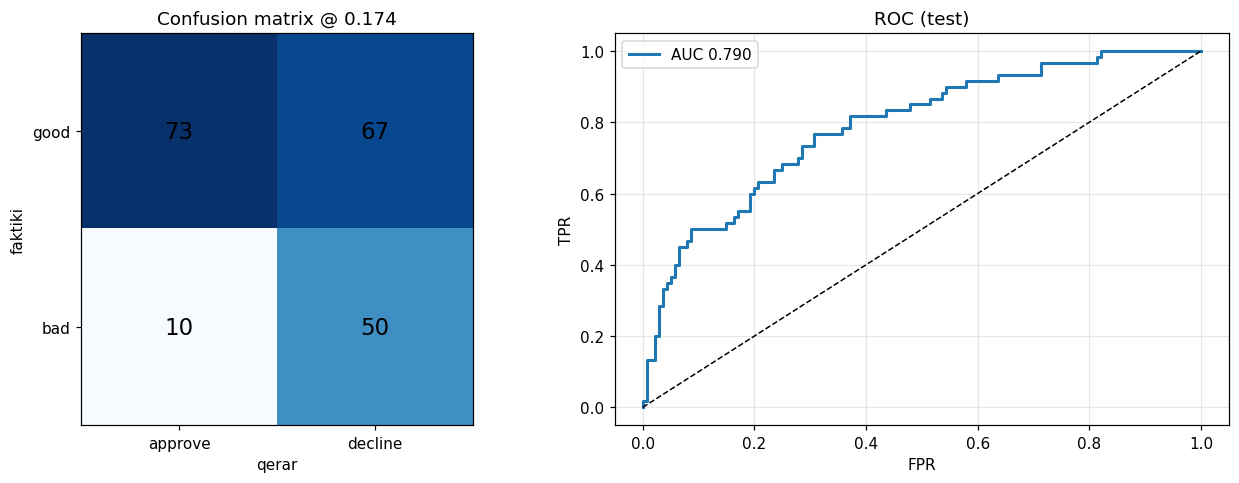

In [23]:
pred_final = (p_test >= THRESHOLD).astype(int)
print(classification_report(y_test, pred_final, target_names=["good", "bad"], digits=3))

cm = confusion_matrix(y_test, pred_final)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i, j], ha="center", va="center", fontsize=15)
ax[0].set_xticks([0, 1], ["approve", "decline"]); ax[0].set_yticks([0, 1], ["good", "bad"])
ax[0].set_xlabel("qerar"); ax[0].set_ylabel("faktiki")
ax[0].set_title(f"Confusion matrix @ {THRESHOLD:.3f}")
ax[0].grid(False)

fpr, tpr, _ = roc_curve(y_test, p_test)
ax[1].plot(fpr, tpr, lw=2, label=f"AUC {roc_auc_score(y_test, p_test):.3f}")
ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title("ROC (test)")
ax[1].legend()

plt.tight_layout(); plt.show()

In [24]:
prep_fitted = final_model.named_steps["prep"]
clf_fitted = final_model.named_steps["clf"]

feat_names = [n.split("__", 1)[-1] for n in prep_fitted.get_feature_names_out()]
Xte_t = pd.DataFrame(prep_fitted.transform(X_test), columns=feat_names, index=X_test.index)

explainer = shap.TreeExplainer(clf_fitted)
sv = explainer(Xte_t)
print(sv.shape)

(200, 58)


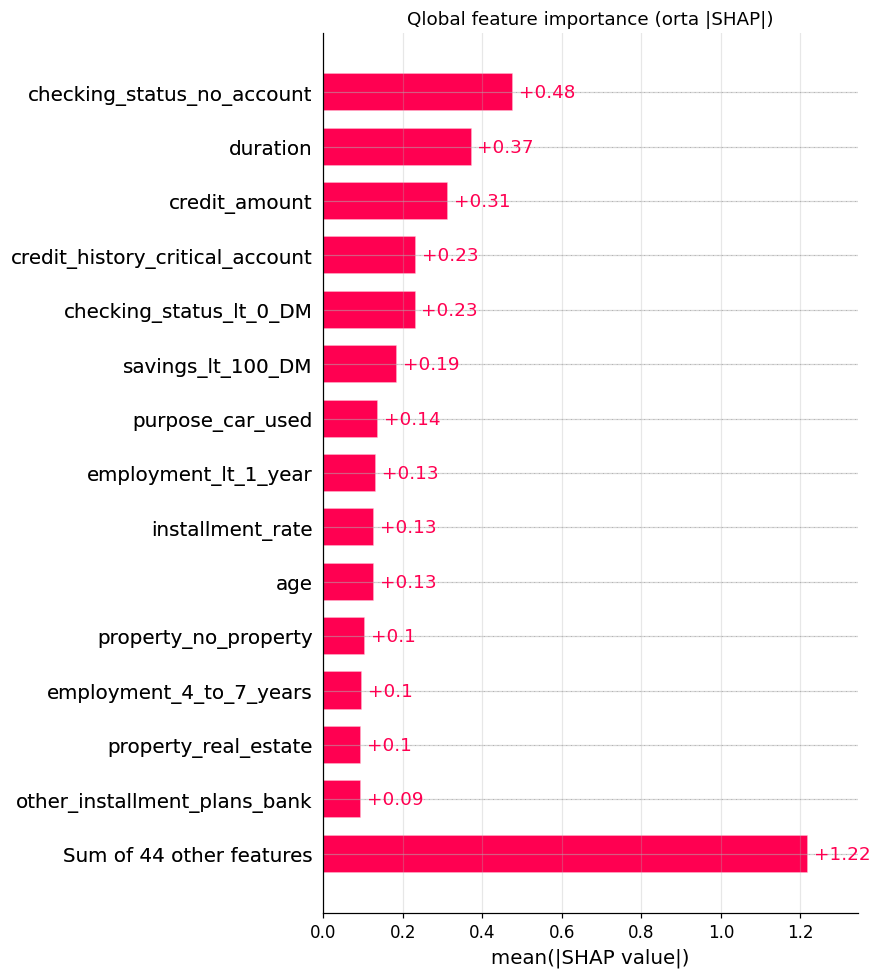

In [25]:
shap.plots.bar(sv, max_display=15, show=False)
plt.title("Qlobal feature importance (orta |SHAP|)")
plt.tight_layout(); plt.show()

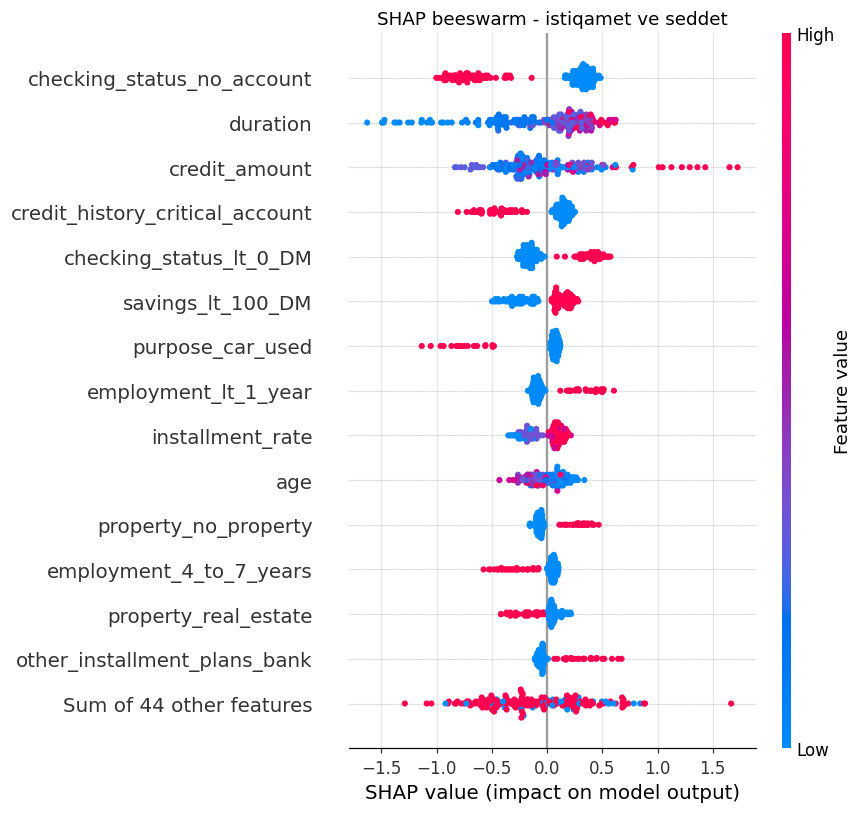

In [26]:
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("SHAP beeswarm - istiqamet ve seddet")
plt.tight_layout(); plt.show()

In [27]:
declined = np.where(pred_final == 1)[0]
i = int(declined[np.argmax(p_test[declined])])

print("default ehtimali :", round(float(p_test[i]), 3))
print("threshold        :", round(THRESHOLD, 3))
print("qerar            : DECLINE\n")
print(X_test.iloc[i][["checking_status", "credit_history", "duration",
                      "credit_amount", "savings", "employment", "age"]])

default ehtimali : 0.914
threshold        : 0.174
qerar            : DECLINE

checking_status                lt_0_DM
credit_history     no_credits_all_paid
duration                            48
credit_amount                     7119
savings                      lt_100_DM
employment                1_to_4_years
age                                 53
Name: 522, dtype: object


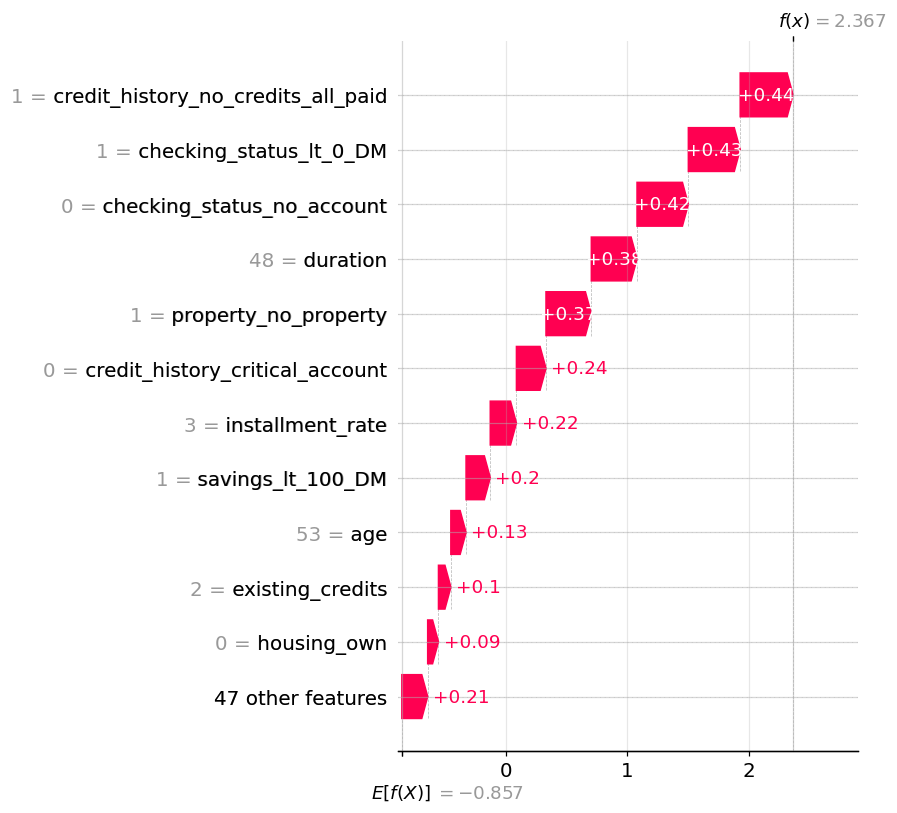

In [28]:
shap.plots.waterfall(sv[i], max_display=12, show=False)
plt.tight_layout(); plt.show()

In [29]:
def to_original(name):
    if name in num_cols:
        return name
    hits = [c for c in cat_cols if name.startswith(c + "_")]
    return max(hits, key=len) if hits else name

owner = pd.Series([to_original(n) for n in feat_names], index=feat_names)

contrib = (pd.Series(sv[i].values, index=feat_names)
             .groupby(owner).sum()
             .sort_values(ascending=False))

print("Redd sebebleri (SHAP tohferine gore):\n")
for name, val in contrib.head(4).items():
    print(f"  {name:22s} = {str(X_test.iloc[i][name]):22s} riski {val:+.3f}")

Redd sebebleri (SHAP tohferine gore):

  checking_status        = lt_0_DM                riski +0.827
  credit_history         = no_credits_all_paid    riski +0.671
  property               = no_property            riski +0.418
  duration               = 48                     riski +0.377


In [30]:
PDO, BASE_SCORE = 20, 600
BASE_ODDS = (1 - y_train.mean()) / y_train.mean()

factor = PDO / np.log(2)
offset = BASE_SCORE - factor * np.log(BASE_ODDS)
print("base odds:", round(BASE_ODDS, 2), "| factor:", round(factor, 1), "| offset:", round(offset, 1))

def to_score(p_bad):
    p_bad = np.clip(p_bad, 1e-6, 1 - 1e-6)
    odds_good = (1 - p_bad) / p_bad
    return offset + factor * np.log(odds_good)

score_test = to_score(p_test)
cutoff_score = to_score(np.array([THRESHOLD]))[0]

print(f"cutoff score: {cutoff_score:.0f}  (bundan asagi -> decline)")
print(pd.Series(score_test).describe().round(1))

base odds: 2.33 | factor: 28.9 | offset: 575.6
cutoff score: 620  (bundan asagi -> decline)
count    200.0
mean     610.2
std       45.2
min      507.2
25%      576.7
50%      609.2
75%      642.2
max      720.0
dtype: float64


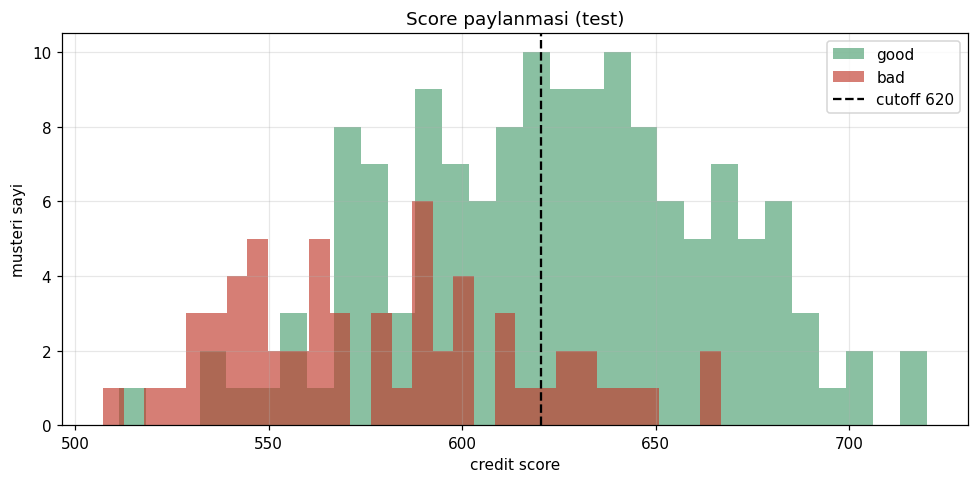

In [31]:
plt.figure(figsize=(9, 4.5))
plt.hist(score_test[y_test == 0], bins=30, alpha=0.65, label="good", color="#4C9F70")
plt.hist(score_test[y_test == 1], bins=30, alpha=0.65, label="bad", color="#C0392B")
plt.axvline(cutoff_score, color="black", ls="--", lw=1.5, label=f"cutoff {cutoff_score:.0f}")
plt.xlabel("credit score"); plt.ylabel("musteri sayi")
plt.title("Score paylanmasi (test)")
plt.legend(); plt.tight_layout(); plt.show()

In [32]:
bands = pd.cut(score_test, bins=[-np.inf, 550, 580, 610, 640, np.inf],
               labels=["<550", "550-580", "580-610", "610-640", "640+"])
band_tbl = (pd.DataFrame({"band": bands, "bad": y_test.values})
              .groupby("band", observed=True)["bad"].agg(["count", "mean"]).round(3))
band_tbl.columns = ["musteri sayi", "faktiki bad rate"]
band_tbl

,musteri sayi,faktiki bad rate
band,,
<550,23,0.783
550-580,33,0.424
580-610,45,0.378
610-640,45,0.156
640+,54,0.074


In [33]:
calibrated = CalibratedClassifierCV(final_model, method="isotonic", cv=cv)
calibrated.fit(X_train, y_train)
p_cal = calibrated.predict_proba(X_test)[:, 1]

print(f"Brier  xam       : {brier_score_loss(y_test, p_test):.4f}")
print(f"Brier  kalibr    : {brier_score_loss(y_test, p_cal):.4f}")
print(f"AUC    xam       : {roc_auc_score(y_test, p_test):.4f}")
print(f"AUC    kalibr    : {roc_auc_score(y_test, p_cal):.4f}")

Brier  xam       : 0.1627
Brier  kalibr    : 0.1621
AUC    xam       : 0.7904
AUC    kalibr    : 0.7890


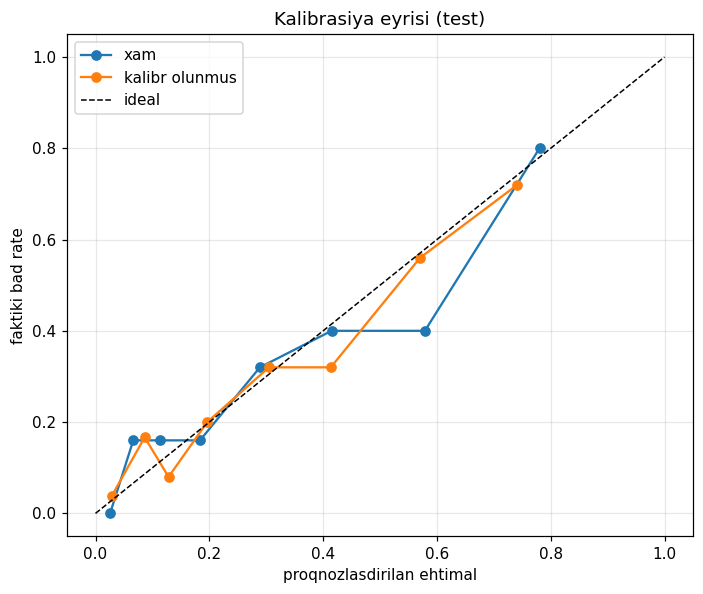

In [34]:
plt.figure(figsize=(6.5, 5.5))
for p, lab in [(p_test, "xam"), (p_cal, "kalibr olunmus")]:
    fr, mp = calibration_curve(y_test, p, n_bins=8, strategy="quantile")
    plt.plot(mp, fr, "o-", label=lab)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="ideal")
plt.xlabel("proqnozlasdirilan ehtimal"); plt.ylabel("faktiki bad rate")
plt.title("Kalibrasiya eyrisi (test)")
plt.legend(); plt.tight_layout(); plt.show()

In [35]:
audit = X_test.copy()
audit["gender"] = np.where(audit["personal_status_sex"] == "female_div_sep_mar", "female", "male")
audit["age_group"] = np.where(audit["age"] < 26, "young", "adult")
audit["y"] = y_test.values
audit["pred"] = pred_final
audit["p"] = p_test

def group_metrics(g):
    rows = []
    for val, sub in audit.groupby(g):
        tn, fp, fn, tp = confusion_matrix(sub["y"], sub["pred"], labels=[0, 1]).ravel()
        rows.append({
            g: val, "n": len(sub),
            "faktiki bad rate": round(sub["y"].mean(), 3),
            "approve rate": round((sub["pred"] == 0).mean(), 3),
            "TPR": round(tp / (tp + fn), 3) if (tp + fn) else np.nan,
            "FPR": round(fp / (fp + tn), 3) if (fp + tn) else np.nan,
            "orta skor": round(sub["p"].mean(), 3),
        })
    return pd.DataFrame(rows)

print(group_metrics("gender"), "\n")
print(group_metrics("age_group"))

   gender    n  faktiki bad rate  approve rate    TPR    FPR  orta skor
0  female   61             0.328         0.311  0.850  0.610      0.338
1    male  139             0.288         0.460  0.825  0.424      0.293 

  age_group    n  faktiki bad rate  approve rate   TPR    FPR  orta skor
0     adult  156             0.256         0.462  0.85  0.431      0.287
1     young   44             0.455         0.250  0.80  0.708      0.377


In [36]:
X_tr_nf = X_train.drop(columns=["personal_status_sex"])
X_te_nf = X_test.drop(columns=["personal_status_sex"])

cat_nf = [c for c in cat_cols if c != "personal_status_sex"]
prep_nf = ColumnTransformer([
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(**ohe_kw), cat_nf),
])

params_nf = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
model_nf = Pipeline([("prep", prep_nf),
                     ("clf", XGBClassifier(eval_metric="logloss", random_state=SEED,
                                           n_jobs=-1, **params_nf))])
model_nf.fit(X_tr_nf, y_train)
p_nf = model_nf.predict_proba(X_te_nf)[:, 1]
pred_nf = (p_nf >= THRESHOLD).astype(int)

print(f"AUC  cins ile   : {roc_auc_score(y_test, p_test):.4f}   cost {total_cost(y_test, pred_final)}")
print(f"AUC  cins yox   : {roc_auc_score(y_test, p_nf):.4f}   cost {total_cost(y_test, pred_nf)}")

AUC  cins ile   : 0.7904   cost 117
AUC  cins yox   : 0.8052   cost 109
